# Baseline: league-specific market-anchored over-2.5 analysis

## Research evolution notebook: separate league-level models

**Research question.** After conditioning on bookmaker consensus probability, do simple prior-match goal-scoring variables add incremental information and produce positive out-of-sample betting returns?

**Result.** No reliable edge is detected. The tested model underperforms the market as a probability forecaster. Full-history returns and CLV are negative at Bet365, Pinnacle, and Betfair Exchange; one positive common-sample Pinnacle result is statistically inconclusive. This notebook presents the evidence; tested implementation code lives in `src/football_edge/`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from football_edge.backtest import (
    bookmaker_coverage,
    build_research_dataset,
    coefficient_stability_summary,
    monthly_roi,
    probability_scores,
    run_walk_forward_with_coefficients,
    select_bets,
    select_bookmaker_bets,
    summarize_bets,
)
from football_edge.config import MINIMUM_EXPECTED_VALUE, RAW_DATA_DIR
from football_edge.data import discover_datasets
from football_edge.plotting import (
    SOURCE_COLORS,
    SOURCE_LABELS,
    plot_coefficient_stability,
    plot_monthly_metric,
    plot_overall_roi_by_execution,
)

pd.options.display.float_format = "{:,.3f}".format
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Hypotheses and research design

The analysis tests three falsifiable hypotheses:

1. **Incremental information:** season-to-date and trailing-five scoring form improves probability forecasts relative to the no-vig pre-closing market.
2. **Economic value:** bets with at least 3% estimated expected value generate positive out-of-sample ROI.
3. **Price discovery:** selected pre-closing bets have positive closing-line value (CLV).

Each league is evaluated separately through time. A test season is predicted using only earlier seasons from the same league. The current match is excluded from every rolling feature with a one-match lag. Closing odds are never model inputs.

In [2]:
datasets = discover_datasets(RAW_DATA_DIR)

dataset_inventory = pd.DataFrame(
    [{"league": item.league, "season": item.season, "file": item.path.name} for item in datasets]
)
dataset_inventory.pivot(index="league", columns="season", values="file").notna()

season,21_22,22_23,23_24,24_25,25_26
league,,,,,
Bundesliga,True,True,True,True,True
La Liga,True,True,True,True,True
Premier League,True,True,True,True,True
Serie A,True,True,True,True,True


## 2. Features and market benchmark

The market-anchored model combines one consensus-price anchor with four incremental form variables:

- the no-vig pre-closing market log-odds for over 2.5 goals;
- home and away season-to-date goals scored;
- home and away average goals scored over their previous five matches.

The market probability is the benchmark. If the form variables contain useful incremental information, the model should achieve a lower out-of-sample Brier score.

In [3]:
all_matches = build_research_dataset(datasets)
predictions, fold_coefficients = run_walk_forward_with_coefficients(all_matches)
scores = probability_scores(predictions)

coverage = (
    all_matches.groupby(["league", "season"])
    .agg(matches=("date", "size"), over_25_rate=("over_2_5", "mean"))
    .reset_index()
)
coverage["over_25_rate"] *= 100

walk_forward_timing = (
    predictions.groupby(["league", "season"])
    .agg(
        predicted_matches=("date", "size"),
        training_seasons=("training_seasons", "first"),
        training_matches=("training_matches", "first"),
        train_end_date=("train_end_date", "first"),
        test_start_date=("test_start_date", "first"),
        model_iterations=("model_iterations", "first"),
    )
    .reset_index()
)
walk_forward_timing["chronology_ok"] = (
    walk_forward_timing["train_end_date"]
    < walk_forward_timing["test_start_date"]
)
assert walk_forward_timing["chronology_ok"].all()
assert predictions["model_probability"].between(0, 1).all()

research_diagnostics = coverage.merge(
    walk_forward_timing, on=["league", "season"], how="left"
)
research_diagnostics

,league,season,matches,over_25_rate,predicted_matches,training_seasons,training_matches,train_end_date,test_start_date,model_iterations,chronology_ok
0,Bundesliga,21_22,306,58.497,NaN,NaN,NaN,NaT,NaT,NaN,NaN
1,Bundesliga,22_23,306,60.458,297.000,1.000,297.000,2022-05-14 14:30:00,2022-08-12 19:30:00,5.000,True
2,Bundesliga,23_24,306,62.418,297.000,2.000,594.000,2023-05-27 14:30:00,2023-08-25 19:30:00,5.000,True
3,Bundesliga,24_25,306,59.804,297.000,3.000,891.000,2024-05-18 14:30:00,2024-08-30 19:30:00,5.000,True
4,Bundesliga,25_26,306,63.725,297.000,4.000,"1,188.000",2025-05-17 14:30:00,2025-08-29 19:30:00,5.000,True
5,La Liga,21_22,380,44.474,NaN,NaN,NaN,NaT,NaT,NaN,NaN
6,La Liga,22_23,380,47.632,370.000,1.000,370.000,2022-05-22 21:00:00,2022-08-19 19:00:00,4.000,True
7,La Liga,23_24,380,46.053,370.000,2.000,740.000,2023-06-04 20:00:00,2023-08-18 18:30:00,4.000,True
8,La Liga,24_25,380,48.684,370.000,3.000,"1,110.000",2024-05-26 20:00:00,2024-08-23 18:00:00,5.000,True
9,La Liga,25_26,380,50.000,370.000,4.000,"1,480.000",2025-05-25 20:00:00,2025-08-22 20:30:00,5.000,True


In [4]:
score_summary = (
    scores.groupby("league")[["brier_model", "brier_market"]]
    .mean()
    .assign(incremental_value=lambda frame: frame["brier_market"] - frame["brier_model"])
)
score_summary

,brier_model,brier_market,incremental_value
league,,,
Bundesliga,0.230,0.229,-0.002
La Liga,0.238,0.237,-0.001
Premier League,0.240,0.238,-0.001
Serie A,0.250,0.246,-0.004


**Interpretation.** Lower Brier scores are better; positive incremental value would favor the model. The observed incremental values are negative across the leagues, so this sample provides no evidence that the form features improve on the market benchmark. This is a descriptive comparison, not a formal test of equal predictive accuracy.

## 3. Walk-forward coefficient stability

The coefficients below come from the same league-specific expanding-window folds used for prediction. Predictors are standardized within each training fold, so slope magnitudes are comparable within the model and approximately comparable through time. Stability is assessed through dispersion, sign consistency, and fold-to-fold sign changes.

Coefficient stability is a diagnostic rather than proof of causality or economic value. A stable coefficient can still be redundant with the market, while an unstable coefficient suggests that its estimated incremental relationship is sensitive to the training sample.

In [5]:
coefficient_report = coefficient_stability_summary(fold_coefficients)
coefficient_report["positive_share_pct"] = (
    coefficient_report.pop("positive_share") * 100
)
coefficient_report.round(3)

,league,coefficient,folds,mean_coefficient,std_coefficient,min_coefficient,max_coefficient,sign_changes,positive_share_pct
0,Bundesliga,away_last_5_avg_goals,4,-0.106,0.086,-0.222,-0.016,0,0.000
1,Bundesliga,away_season_avg_goals,4,0.174,0.126,0.051,0.331,0,100.000
2,Bundesliga,home_last_5_avg_goals,4,-0.067,0.047,-0.108,-0.009,0,0.000
3,Bundesliga,home_season_avg_goals,4,0.113,0.123,-0.044,0.253,2,75.000
4,Bundesliga,market_logit,4,0.380,0.029,0.341,0.412,0,100.000
5,La Liga,away_last_5_avg_goals,4,0.010,0.055,-0.046,0.075,2,50.000
6,La Liga,away_season_avg_goals,4,-0.087,0.060,-0.151,-0.012,0,0.000
7,La Liga,home_last_5_avg_goals,4,-0.014,0.054,-0.074,0.057,1,25.000
8,La Liga,home_season_avg_goals,4,-0.117,0.058,-0.176,-0.052,0,0.000
9,La Liga,market_logit,4,0.461,0.090,0.337,0.542,0,100.000


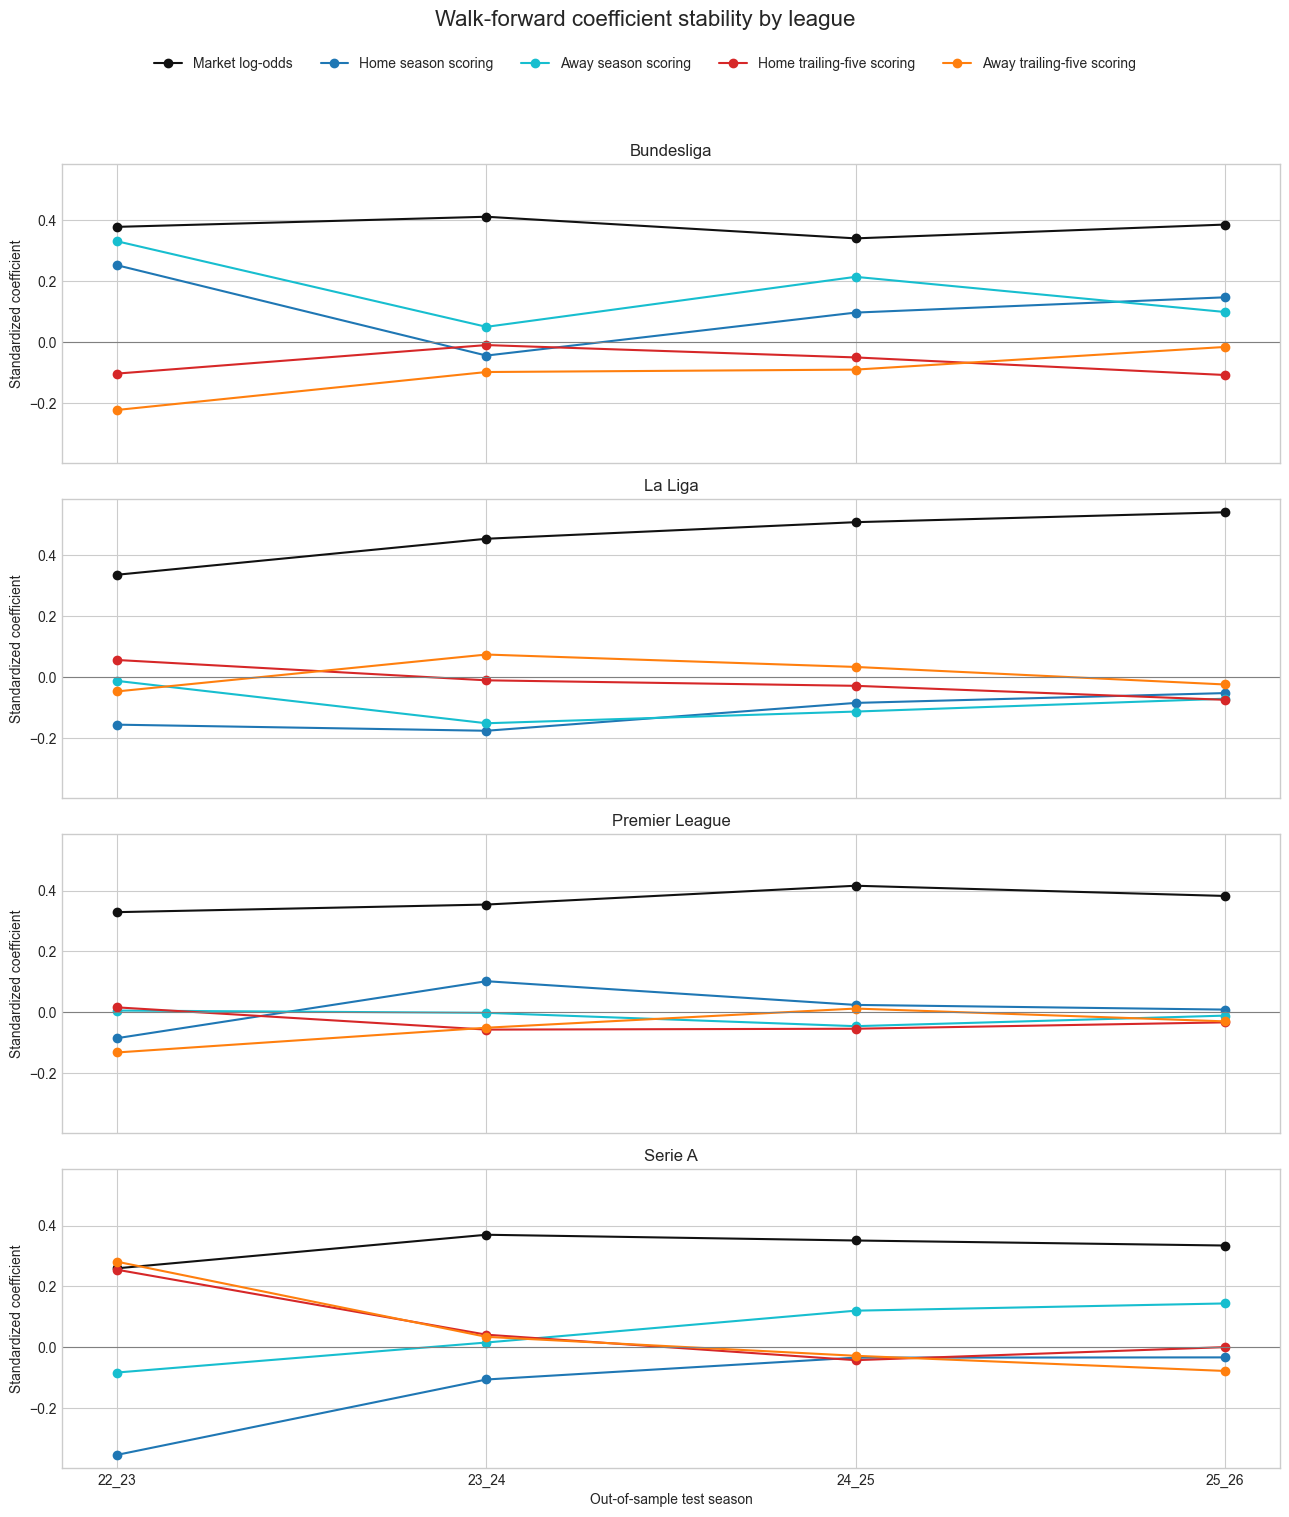

In [6]:
plot_coefficient_stability(fold_coefficients)
plt.show()

**Observed stability.** `market_logit` is positive in all 16 folds, has no sign changes, and is the largest standardized slope in every league. The scoring-form coefficients are materially less stable: several change sign across test seasons, remain close to zero in the Premier League, or exhibit league-specific directions. Bundesliga season averages are mostly positive while trailing-five coefficients are consistently negative; La Liga season coefficients are consistently negative; and Serie A form estimates have comparatively high dispersion. This pattern indicates that the market signal is persistent but the incremental relationship of the simple form variables is not portable across leagues or consistently stable through time.

## 4. Execution-price betting backtest

A flat one-unit over 2.5 bet is placed when:

$$\hat{p}_{model} \times \text{decimal odds} - 1 \geq 3\%$$

Every scenario receives the exact same `model_probability`; only its execution-price proxy changes. Bets are selected independently because EV depends on that price:

- **Bet365:** `B365>2.5`, with CLV measured against `B365C>2.5`.
- **Pinnacle:** `P>2.5`, with CLV measured against `PC>2.5`.
- **Betfair Exchange:** `BFE>2.5`, with CLV measured against `BFEC>2.5`. Results use gross quoted odds with 0% commission because the dataset does not specify an account-specific rate.
- **Market average:** `Avg>2.5`, retained as a broad-market benchmark.
- **Market maximum:** `Max>2.5`, retained as an optimistic best-recorded-price benchmark.

Betfair coverage begins only in 2024/25. Results are therefore shown both on each source's full available history and on the common subset where all three sources have valid pre-closing and closing quotes.

In [7]:
full_coverage = bookmaker_coverage(predictions, common_sample=False)
common_coverage = bookmaker_coverage(predictions, common_sample=True)
coverage_by_source = pd.concat([full_coverage, common_coverage], ignore_index=True)
coverage_by_source

,bookmaker,available_matches,comparison_matches,coverage_pct,common_sample
0,bet365,5628,5628,100.000,False
1,pinnacle,4865,5628,86.443,False
2,betfair_exchange,2705,5628,48.063,False
3,bet365,2073,2073,100.000,True
4,pinnacle,2073,2073,100.000,True
5,betfair_exchange,2073,2073,100.000,True


,execution_source,bets,wins,win_rate_pct,average_odds,profit_units,roi_pct,roi_95_low_pct,roi_95_high_pct,mean_clv_pct,max_drawdown_units
0,bet365,488,246,50.410,1.810,-53.970,-11.060,-19.140,-2.970,-0.440,57.020
1,betfair_exchange,517,304,58.800,1.710,-10.860,-2.100,-9.390,5.190,-0.650,25.050
2,pinnacle,619,323,52.180,1.840,-43.520,-7.030,-14.290,0.230,-1.070,55.620
3,average_preclosing,377,196,51.990,1.810,-30.380,-8.060,-17.290,1.170,-0.720,42.230
4,best_preclosing,1007,531,52.730,1.820,-73.480,-7.300,-12.900,-1.700,-1.540,79.880


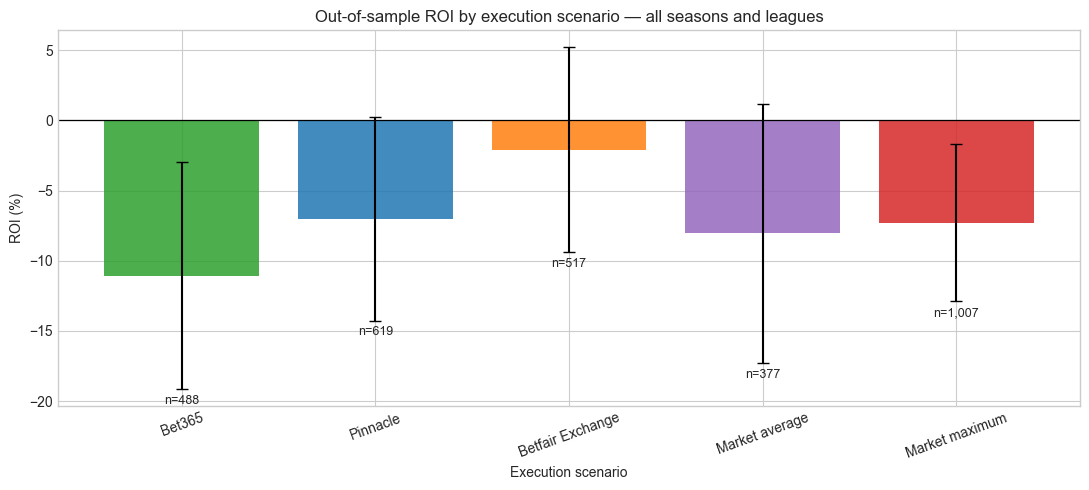

In [8]:
bookmaker_bets = select_bookmaker_bets(
    predictions,
    minimum_expected_value=MINIMUM_EXPECTED_VALUE,
    common_sample=False,
)
common_sample_bets = select_bookmaker_bets(
    predictions,
    minimum_expected_value=MINIMUM_EXPECTED_VALUE,
    common_sample=True,
)

# Retain the aggregate market average and maximum as research benchmarks.
market_bets = select_bets(
    predictions,
    minimum_expected_value=MINIMUM_EXPECTED_VALUE,
)

# Standardized bet-level table used for time-series diagnostics.
execution_bets = pd.concat(
    [
        bookmaker_bets.rename(columns={"bookmaker": "execution_source"}),
        market_bets.rename(columns={"price_scenario": "execution_source"}),
    ],
    ignore_index=True,
)

bookmaker_season_performance = summarize_bets(
    bookmaker_bets, ["bookmaker", "league", "season"]
).rename(columns={"bookmaker": "execution_source"})
market_season_performance = summarize_bets(
    market_bets, ["price_scenario", "league", "season"]
).rename(columns={"price_scenario": "execution_source"})
performance_by_season = pd.concat(
    [bookmaker_season_performance, market_season_performance],
    ignore_index=True,
).round(2)

bookmaker_overall = summarize_bets(
    bookmaker_bets, ["bookmaker"]
).rename(columns={"bookmaker": "execution_source"})
market_overall = summarize_bets(
    market_bets, ["price_scenario"]
).rename(columns={"price_scenario": "execution_source"})
overall_performance = pd.concat(
    [bookmaker_overall, market_overall], ignore_index=True
).round(2)
common_sample_performance = summarize_bets(
    common_sample_bets, ["bookmaker"]
).round(2)

display(overall_performance)
plot_overall_roi_by_execution(
    overall_performance,
    title="Out-of-sample ROI by execution scenario — all seasons and leagues",
)
plt.show()

In [9]:
# Like-for-like comparison on matches quoted by all three sources.
common_sample_performance

,bookmaker,bets,wins,win_rate_pct,average_odds,profit_units,roi_pct,roi_95_low_pct,roi_95_high_pct,mean_clv_pct,max_drawdown_units
0,bet365,134,80,59.700,1.650,-6.100,-4.550,-18.190,9.080,0.020,12.080
1,betfair_exchange,436,258,59.170,1.710,-4.000,-0.920,-8.860,7.030,-0.550,24.170
2,pinnacle,201,127,63.180,1.680,6.360,3.160,-8.080,14.410,-0.870,8.470


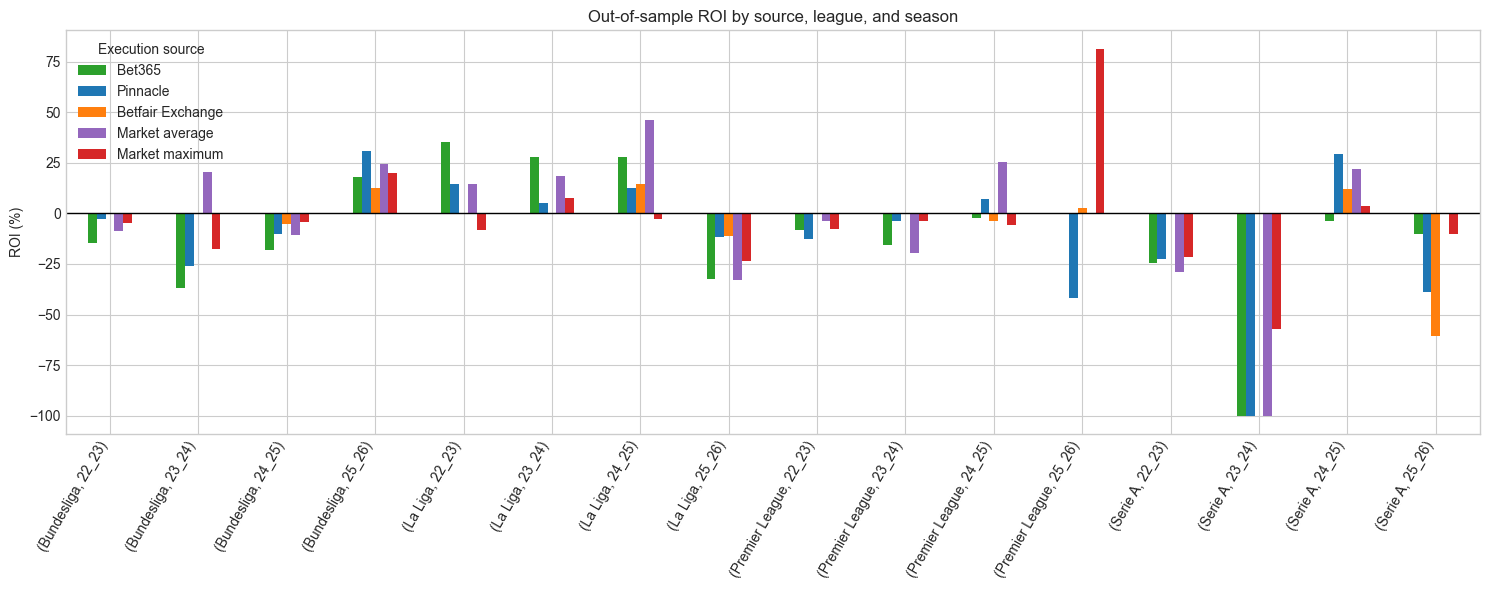

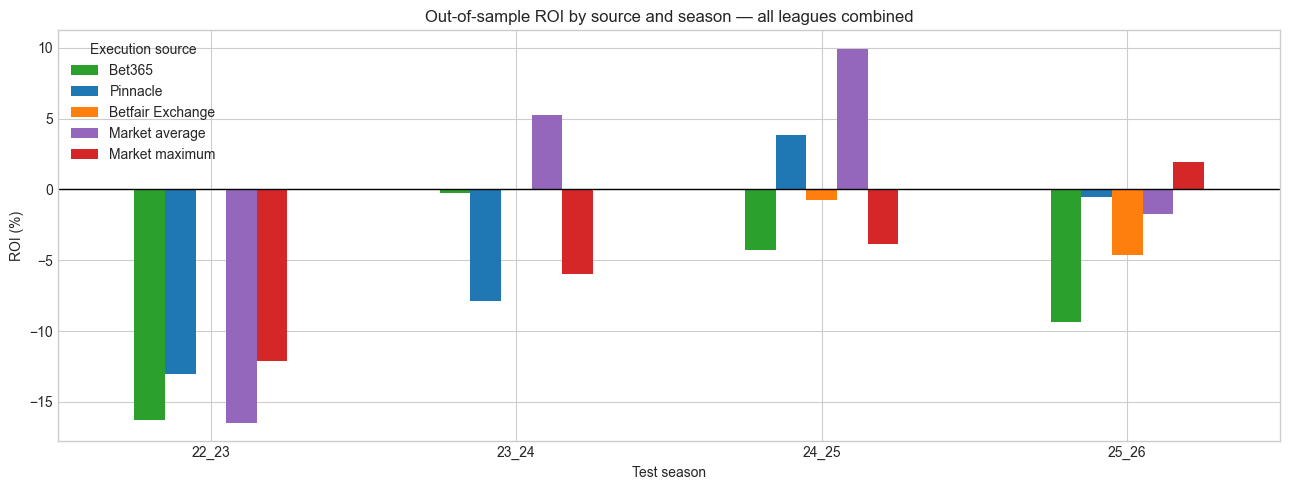

In [10]:
plot_data = performance_by_season.copy()
plot_data["execution_source"] = plot_data["execution_source"].map(SOURCE_LABELS)
source_order = [
    SOURCE_LABELS[source]
    for source in performance_by_season["execution_source"].unique()
]
roi_matrix = (
    plot_data.pivot_table(
        index=["league", "season"],
        columns="execution_source",
        values="roi_pct",
    )
    .reindex(columns=source_order)
)

ax = roi_matrix.plot(
    kind="bar",
    figsize=(15, 6),
    color=[SOURCE_COLORS[source] for source in roi_matrix.columns],
)
ax.axhline(0, color="black", linewidth=1)
ax.set(title="Out-of-sample ROI by source, league, and season", ylabel="ROI (%)", xlabel="")
ax.legend(title="Execution source")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# Aggregate all leagues before calculating each season's ROI. This is total
# profit divided by total one-unit stakes, not an average of league ROIs.
all_league_season_performance = summarize_bets(
    execution_bets, ["execution_source", "season"]
)
all_league_plot_data = all_league_season_performance.copy()
all_league_plot_data["execution_source"] = all_league_plot_data["execution_source"].map(SOURCE_LABELS)
all_league_roi_matrix = (
    all_league_plot_data.pivot(
        index="season",
        columns="execution_source",
        values="roi_pct",
    )
    .reindex(columns=source_order)
)

ax = all_league_roi_matrix.plot(
    kind="bar",
    figsize=(13, 5),
    color=[SOURCE_COLORS[source] for source in all_league_roi_matrix.columns],
)
ax.axhline(0, color="black", linewidth=1)
ax.set(
    title="Out-of-sample ROI by source and season — all leagues combined",
    ylabel="ROI (%)",
    xlabel="Test season",
)
ax.legend(title="Execution source", frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Monthly ROI diagnostics

Monthly ROI is calculated as realized profit divided by the number of one-unit stakes placed in that calendar month. It is not an average of match-level percentages. Months with no bets are left as gaps rather than reported as 0%.

Monthly estimates can be extremely noisy when only a few bets qualify. The sample-size table should therefore be read alongside the five plots; isolated monthly spikes are descriptive diagnostics, not evidence of a stable edge.

In [11]:
monthly_by_league = monthly_roi(
    execution_bets, ["league", "execution_source"]
)
monthly_all_leagues = monthly_roi(
    execution_bets, ["execution_source"]
)

monthly_for_summary = pd.concat(
    [
        monthly_by_league,
        monthly_all_leagues.assign(league="All leagues"),
    ],
    ignore_index=True,
)
monthly_sample_sizes = (
    monthly_for_summary.groupby(["league", "execution_source"])["bets"]
    .agg(months="size", min_bets="min", median_bets="median", max_bets="max")
    .reset_index()
)
monthly_sample_sizes["execution_source"] = monthly_sample_sizes[
    "execution_source"
].map(SOURCE_LABELS)
monthly_sample_sizes

,league,execution_source,months,min_bets,median_bets,max_bets
0,All leagues,Market average,39,1,6.000,32
1,All leagues,Market maximum,41,2,23.000,61
2,All leagues,Bet365,41,2,9.000,40
3,All leagues,Betfair Exchange,20,10,25.000,45
4,All leagues,Pinnacle,37,1,13.000,54
5,Bundesliga,Market average,30,1,2.500,12
6,Bundesliga,Market maximum,39,2,7.000,22
7,Bundesliga,Bet365,36,1,3.500,15
8,Bundesliga,Betfair Exchange,20,2,7.000,14
9,Bundesliga,Pinnacle,33,1,5.000,17


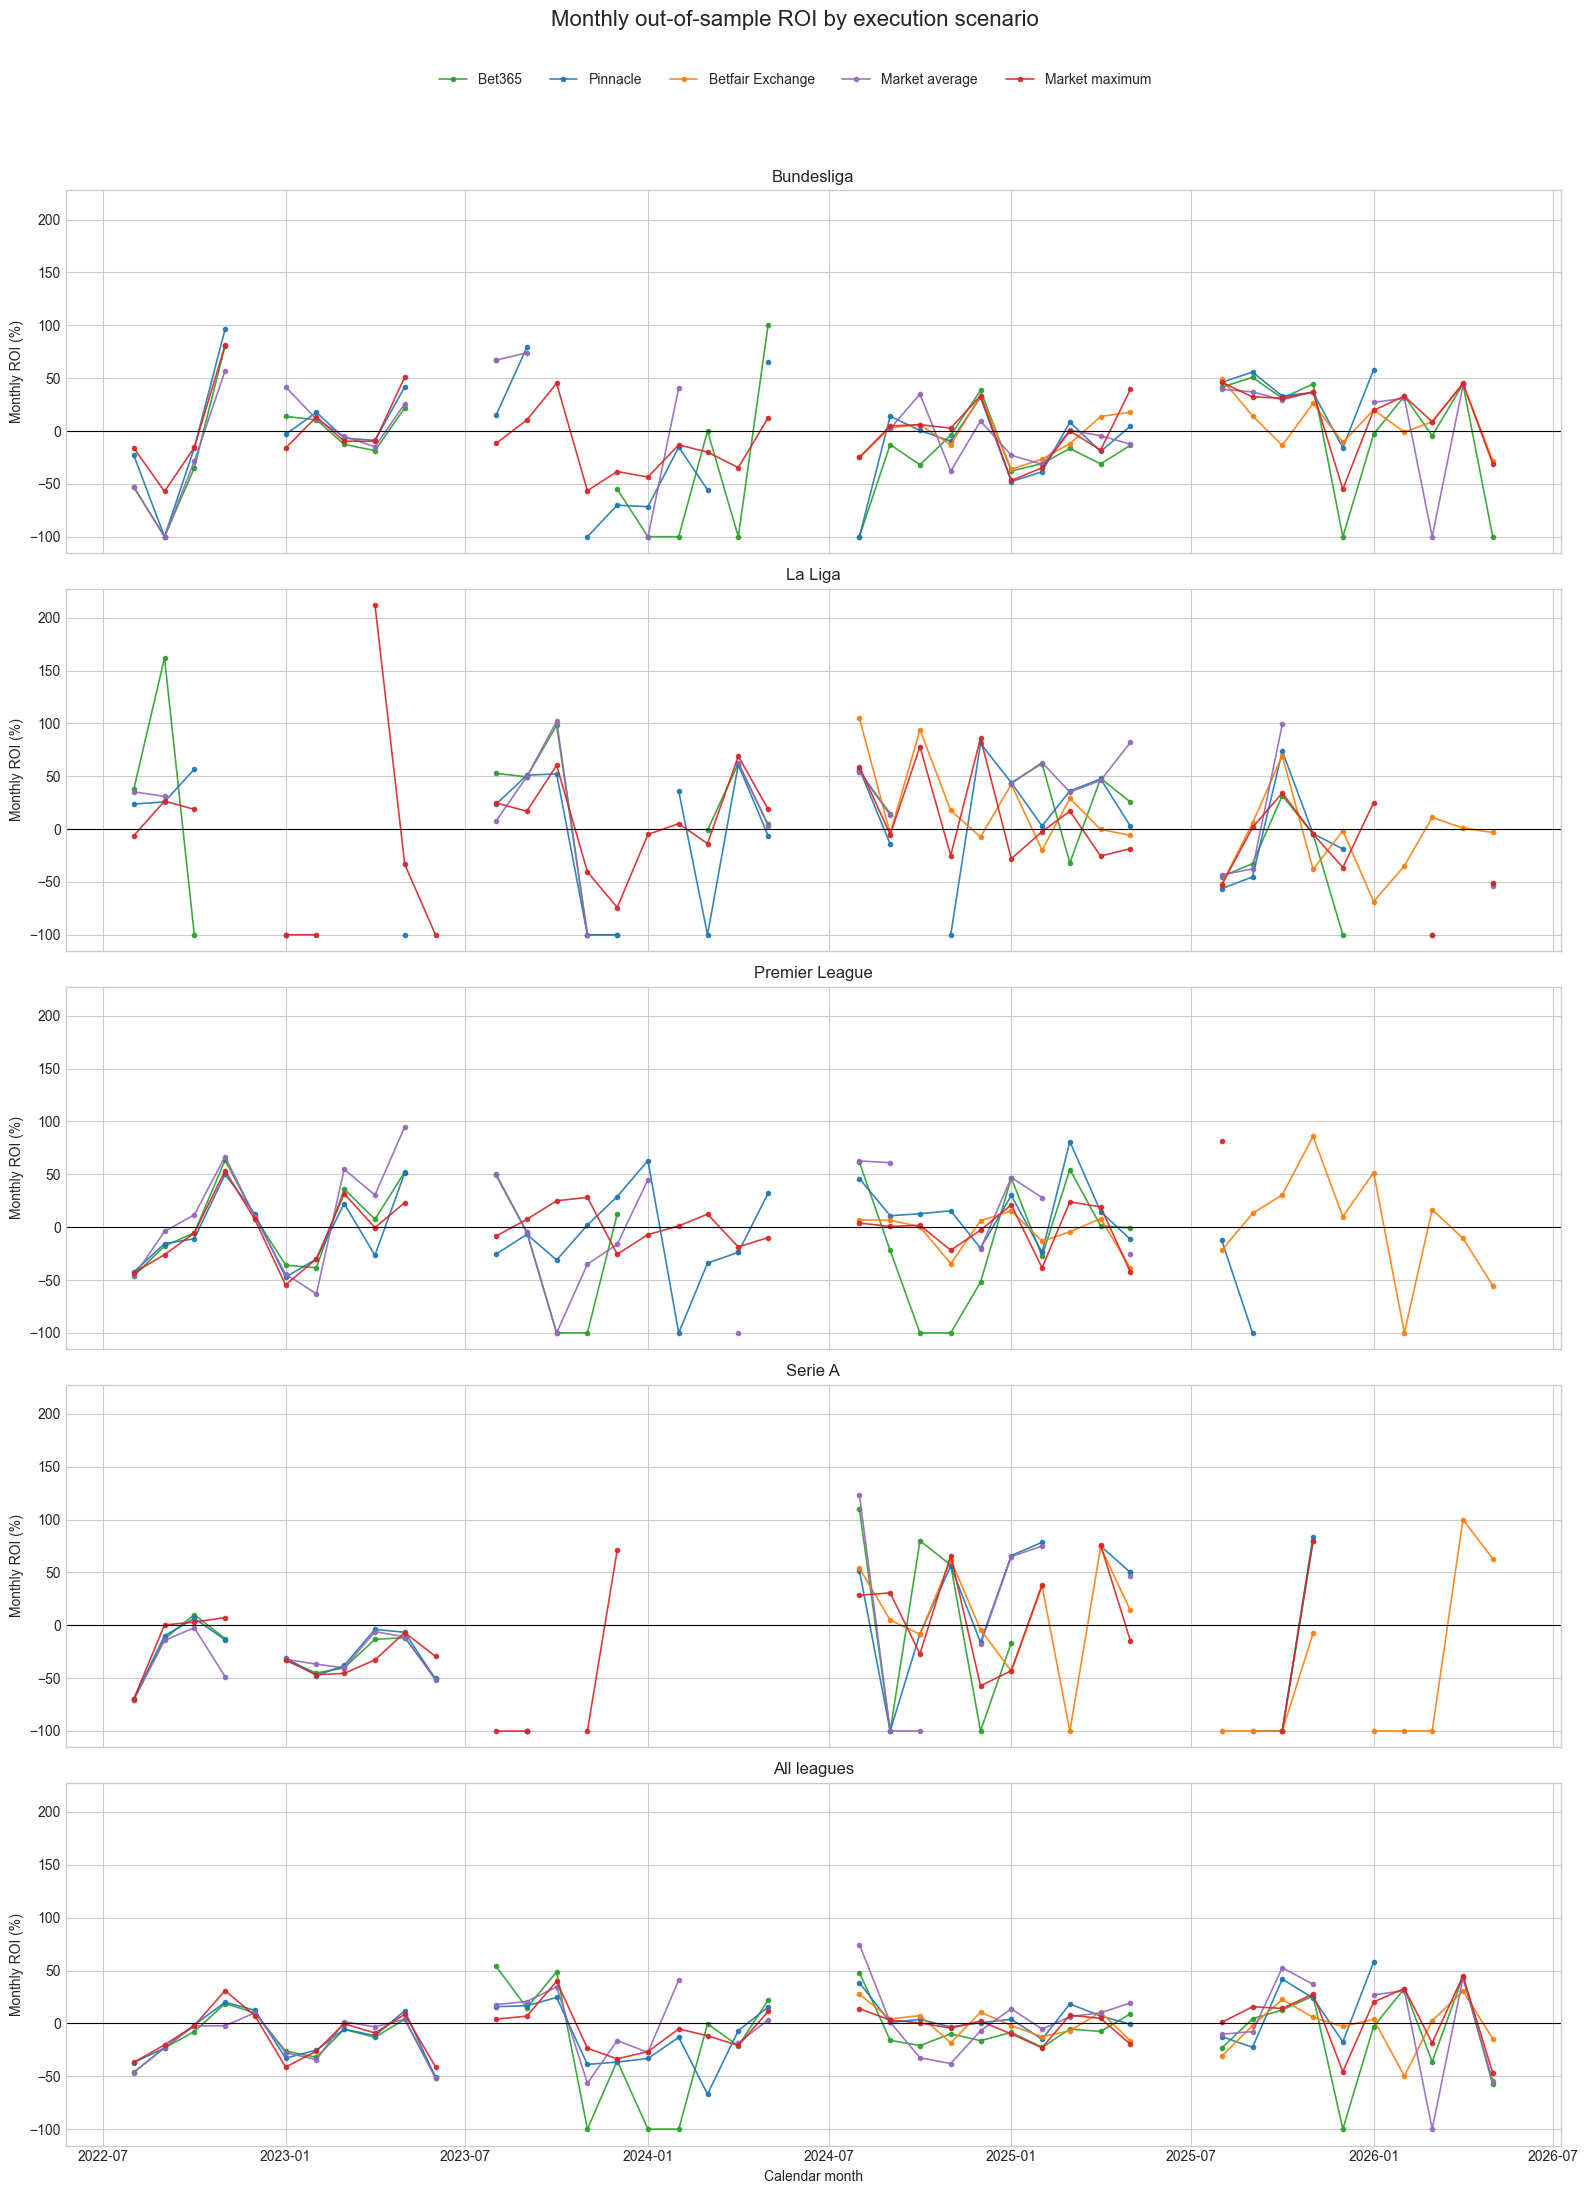

In [12]:
plot_monthly_metric(
    monthly_by_league,
    monthly_all_leagues,
    value_column="roi_pct",
    title="Monthly out-of-sample ROI by execution scenario",
    y_label="Monthly ROI (%)",
    show_zero_line=True,
)
plt.show()

## 6. Monthly betting activity

The following five panels show the number of matches on which each execution scenario triggers a bet per calendar month. This is a strategy-activity diagnostic, not a profitability measure. Unlike monthly ROI, a month with no qualifying bets is correctly represented as zero.

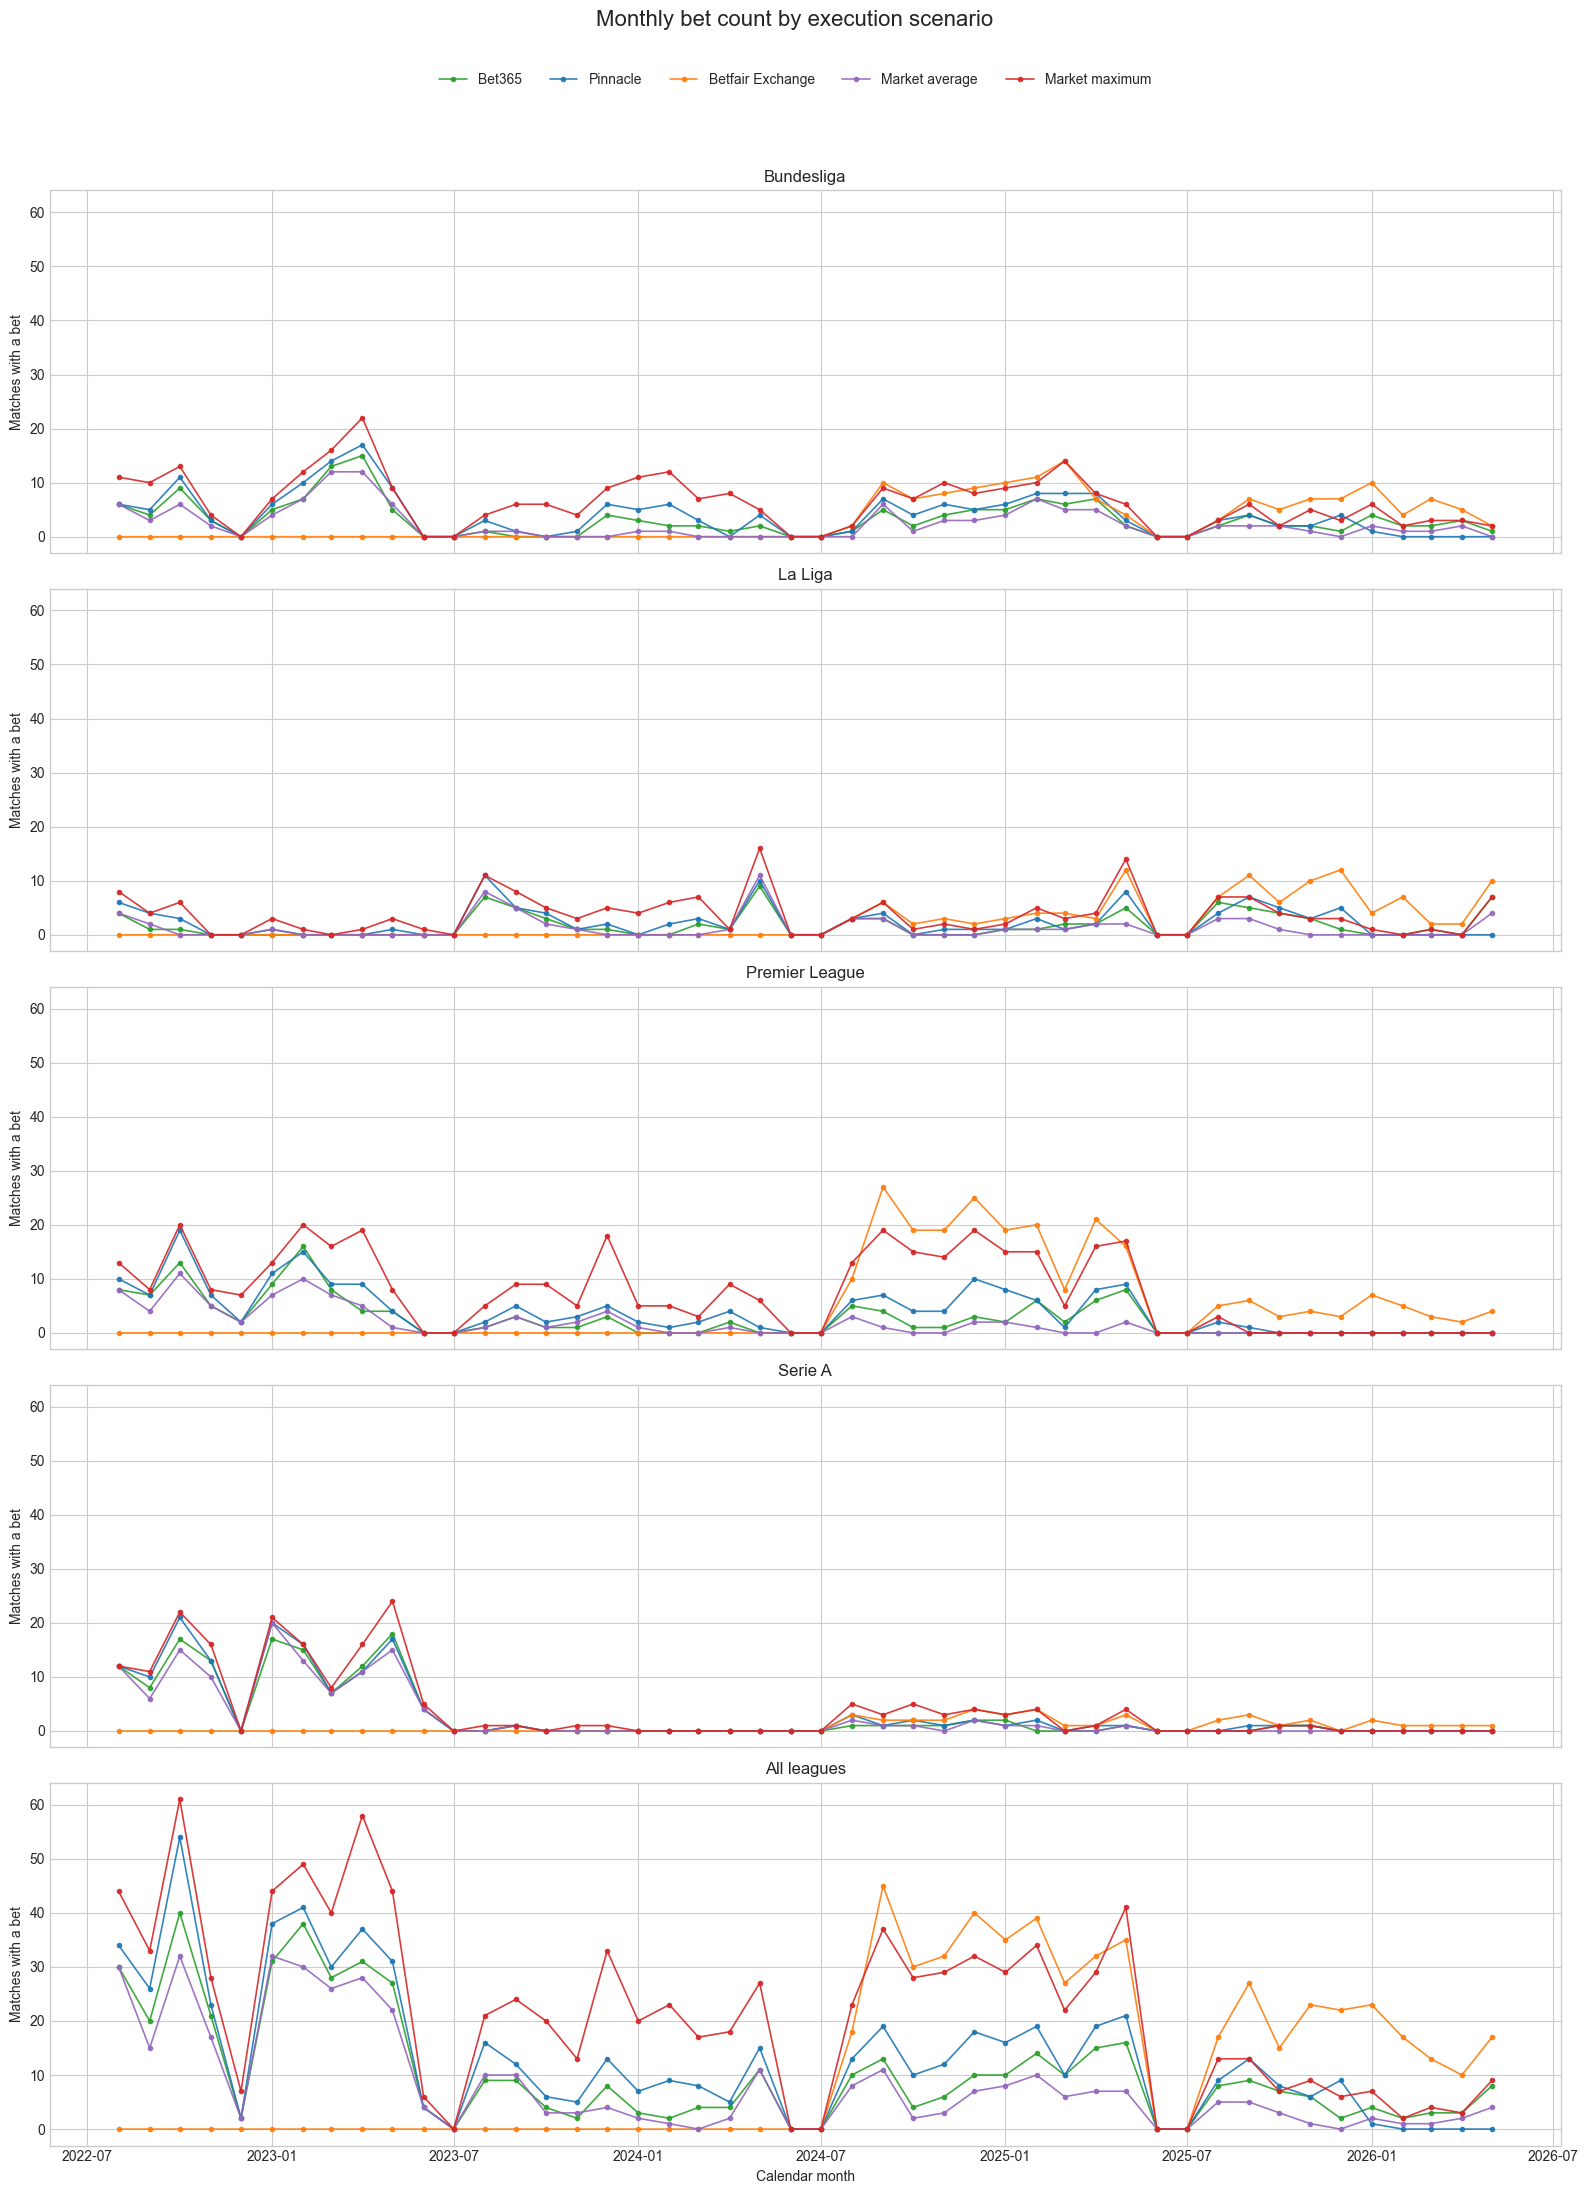

In [13]:
plot_monthly_metric(
    monthly_by_league,
    monthly_all_leagues,
    value_column="bets",
    title="Monthly bet count by execution scenario",
    y_label="Matches with a bet",
    fill_missing=0,
)
plt.show()

## 7. Conclusion

The evidence does not support the three hypotheses for this specification:

1. The model's Brier score is slightly worse than the no-vig market benchmark.
2. On each source's full available history, ROI is **-11.1% at Bet365**, **-7.0% at Pinnacle**, and **-2.1% at Betfair Exchange** using gross exchange odds with 0% commission.
3. The aggregate benchmarks also lose money: **-8.1% at the market average** and **-7.3% at the market maximum**.
4. Mean CLV is negative for all five full-sample scenarios.

On the common quoted-match subset, Pinnacle returns **+3.2%**, but its approximate 95% ROI interval spans **-8.1% to +14.4%** and its mean CLV is negative. This isolated result is not statistically persuasive evidence of an edge.

The practical lesson is that predictive hit rate is not economic edge. Bookmaker prices already encode much of the information in recent scoring form, and a strategy must beat both that information benchmark and the market margin.

### Limitations and next research directions

- Historical source-specific odds are execution proxies; the recorded quote may not always have been obtainable at bet time.
- Betfair Exchange appears only in recent seasons. Results are gross of commission; an account-specific rate should be tested separately.
- Full-history comparisons use unequal coverage; the common-sample table provides the like-for-like comparison.
- The features omit goals conceded, opponent strength, expected goals, injuries, and lineups.
- ROI confidence intervals are approximate and do not capture every dependence structure.
- Any future feature or threshold selection must remain inside a nested chronological validation process.
- A natural extension is a hierarchical expected-goals model with team attack/defence strength, evaluated against the same market and CLV benchmarks.

A negative, reproducible result is preferable to an optimized in-sample story: this specification does not justify a bet.